Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**  
Course: **Computer Engineering - Artificial Intelligence / Machine Learning**

**ASSESSMENT 1 - 10 Types of Slope Prediction Models**


---

#### **I. Import Libraries and Initialize Functions**

In [ ]:
import tensorflow as tf 
import pandas as pd 
import numpy as np 
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f'tensorflow: {tf.__version__}\n', 
      f'pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}')

I0000 00:00:1778752441.463207     931 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow: 2.21.0
 pandas: 3.0.2
 numpy: 2.4.2
 sklearn: 1.8.0


In [3]:
def pltpred (train_data, 
             train_labels,
             test_data, 
             test_labels,
             predictions):
    
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", label="Training data")
    plt.scatter(test_data, test_labels, c="g", label="Testing data")
    plt.scatter(test_data, predictions, c="r", label="Predictions")
    plt.legend();

#### **II. Prep Dataset**

Create the dataset.

In [7]:
# Create features
x = np.arange(-200, 200, 4)

# Create labels
y = x + 20


x, y 

(array([-200, -196, -192, -188, -184, -180, -176, -172, -168, -164, -160,
        -156, -152, -148, -144, -140, -136, -132, -128, -124, -120, -116,
        -112, -108, -104, -100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,
         -68,  -64,  -60,  -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,
         -24,  -20,  -16,  -12,   -8,   -4,    0,    4,    8,   12,   16,
          20,   24,   28,   32,   36,   40,   44,   48,   52,   56,   60,
          64,   68,   72,   76,   80,   84,   88,   92,   96,  100,  104,
         108,  112,  116,  120,  124,  128,  132,  136,  140,  144,  148,
         152,  156,  160,  164,  168,  172,  176,  180,  184,  188,  192,
         196]),
 array([-180, -176, -172, -168, -164, -160, -156, -152, -148, -144, -140,
        -136, -132, -128, -124, -120, -116, -112, -108, -104, -100,  -96,
         -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,  -56,  -52,
         -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,  -12,   -8,
          -4,    0,   

Split the dataset into training and testing sets.

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size= 0.2,
                                                    random_state=42,
                                                    shuffle=False
                                                    )

Normalize the data using `StandardScaler()` (for models that require it)

In [9]:
scaler = StandardScaler()

x_train_reshaped = x_train.reshape(-1, 1)
x_test_reshaped = x_test.reshape(-1, 1)

x_train_scaled = scaler.fit_transform(x_train_reshaped)
x_test_scaled = scaler.transform(x_test_reshaped)

x_train_scaled, x_test_scaled, x_train, x_test

(array([[-1.71053381],
        [-1.66722916],
        [-1.62392451],
        [-1.58061985],
        [-1.5373152 ],
        [-1.49401055],
        [-1.45070589],
        [-1.40740124],
        [-1.36409659],
        [-1.32079193],
        [-1.27748728],
        [-1.23418262],
        [-1.19087797],
        [-1.14757332],
        [-1.10426866],
        [-1.06096401],
        [-1.01765936],
        [-0.9743547 ],
        [-0.93105005],
        [-0.8877454 ],
        [-0.84444074],
        [-0.80113609],
        [-0.75783144],
        [-0.71452678],
        [-0.67122213],
        [-0.62791748],
        [-0.58461282],
        [-0.54130817],
        [-0.49800352],
        [-0.45469886],
        [-0.41139421],
        [-0.36808955],
        [-0.3247849 ],
        [-0.28148025],
        [-0.23817559],
        [-0.19487094],
        [-0.15156629],
        [-0.10826163],
        [-0.06495698],
        [-0.02165233],
        [ 0.02165233],
        [ 0.06495698],
        [ 0.10826163],
        [ 0

Visualize the data.

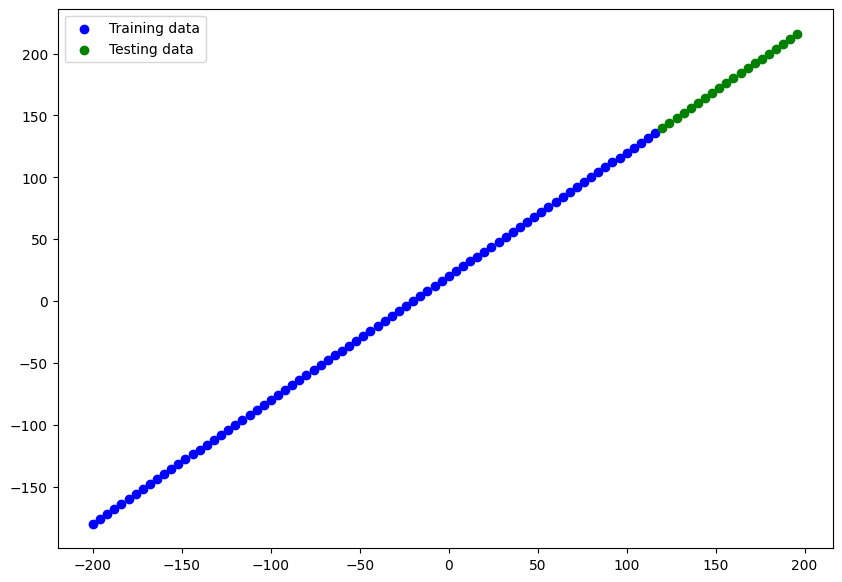

In [10]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(x_train, y_train, c='b', label='Training data')
# Plot test data in green
plt.scatter(x_test, y_test, c='g', label='Testing data')
# Show the legend
plt.legend();

#### **III. Create Models**

#### **Model 1 - Barebone Single Neuron Approach**

The simplest / barebones model.

##### Create and compile model

In [7]:
model1 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1)
])

model1.compile(loss='mse',
              optimizer='adam',
              metrics=["mse"]
              )

I0000 00:00:1778691016.963841   99551 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


##### Show model summary

In [8]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [9]:
history1 = model1.fit(x_train, y_train, 
                      epochs=5)

Epoch 1/5


I0000 00:00:1778691019.375099   99755 service.cc:153] XLA service 0x7d3a7802fa90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778691019.375166   99755 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1778691019.401710   99755 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778691019.468831   99755 cuda_dnn.cc:461] Loaded cuDNN version 92000


1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - loss: 1839.0228 - mse: 1839.0228

I0000 00:00:1778691019.736766   99755 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - loss: 1700.8577 - mse: 1700.8577
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1677.4697 - mse: 1677.4697
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1656.9320 - mse: 1656.9320
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1634.5254 - mse: 1634.5254
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1613.1624 - mse: 1613.1624


Evaluate the model.

In [10]:
model1.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - loss: 7895.5415 - mse: 7895.5415


[7895.54150390625, 7895.54150390625]

##### Showcase results.

In [11]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

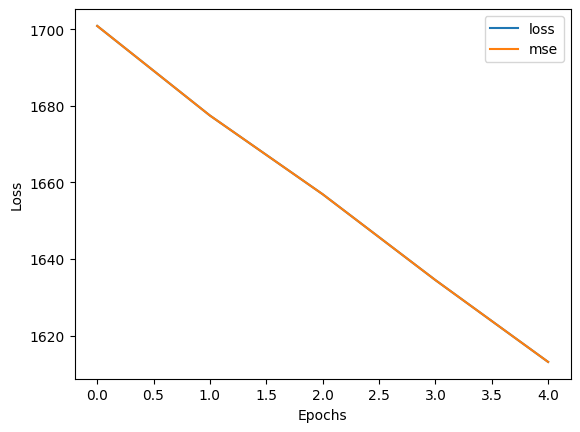

In [12]:
pd.DataFrame(history1.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


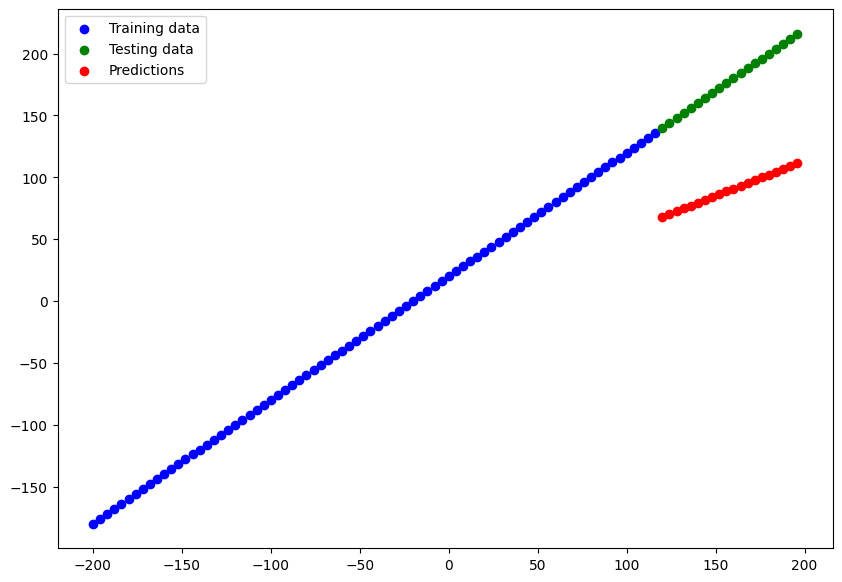

In [13]:
pred1 = model1.predict(x_test)

pltpred(x_train, y_train,
        x_test, y_test,
        pred1
        )

#### **Model 2 - Improved Single Neuron Approach**

Same setup as Model 1 but with some modifications such as increasing epoch count and using normalized features for `.fit()`.

##### Create and compile model

In [14]:
model2 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1)
])

model2.compile(loss='mse',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              metrics=["mse"]
              )

##### Show model summary

In [15]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [16]:
history2 = model2.fit(x_train_scaled, y_train, 
                      epochs=600)

Epoch 1/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - loss: 9250.9346 - mse: 9250.9346
Epoch 2/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9183.4346 - mse: 9183.4346
Epoch 3/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9118.6670 - mse: 9118.6670 
Epoch 4/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9052.5713 - mse: 9052.5713
Epoch 5/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8990.1113 - mse: 8990.1113
Epoch 6/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8921.8174 - mse: 8921.8174
Epoch 7/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8860.6270 - mse: 8860.6270
Epoch 8/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8791.5225 - mse: 8791.5225
Epoch 9/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8733.8457 - mse: 8733.8457  
Epoch 10/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8666.9561 - mse: 8666.9561
Epoch 11/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8605.3281 - mse: 8605.3281
Epoch 12/600
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 

Evaluate the model.

In [17]:
model2.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 38.0807 - mse: 38.0807


[38.080650329589844, 38.080650329589844]

##### Showcase results.

In [18]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

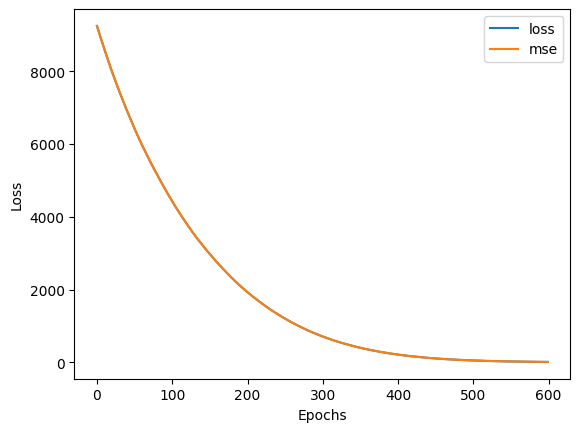

In [19]:
pd.DataFrame(history2.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


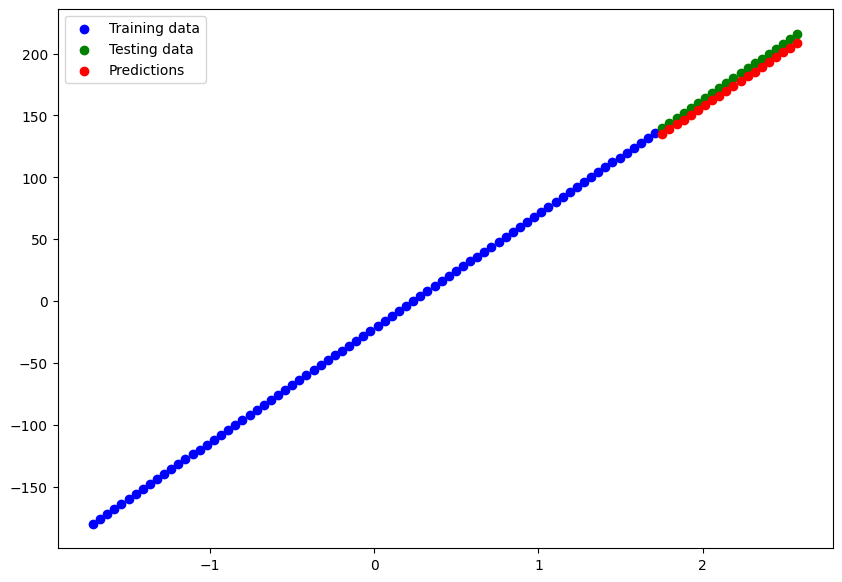

In [20]:
pred2 = model2.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred2
        )

#### **Model 3 - Two Layer Approach**

A model with two layers with the same neuron.

##### Create and compile model

In [28]:
model3 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

model3.compile(loss='mse',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mse"]
              )

##### Show model summary

In [29]:
model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [30]:
history3 = model3.fit(x_train_scaled, y_train, 
                      epochs=400)

Epoch 1/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - loss: 8659.9023 - mse: 8659.9023
Epoch 2/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8640.7822 - mse: 8640.7822
Epoch 3/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8622.6172 - mse: 8622.6172
Epoch 4/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8605.0449 - mse: 8605.0449  
Epoch 5/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8584.0088 - mse: 8584.0088
Epoch 6/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8566.3242 - mse: 8566.3242  
Epoch 7/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8544.8359 - mse: 8544.8359
Epoch 8/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8524.8369 - mse: 8524.8369
Epoch 9/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8504.3447 - mse: 8504.3447
Epoch 10/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8483.5420 - mse: 8483.5420
Epoch 11/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8461.5195 - mse: 8461.5195
Epoch 12/400
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss:

Evaluate the model.

In [31]:
model3.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - loss: 0.2477 - mse: 0.2477


[0.24771106243133545, 0.24771106243133545]

##### Showcase results.

In [35]:
model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (60.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10 (44.00 B)

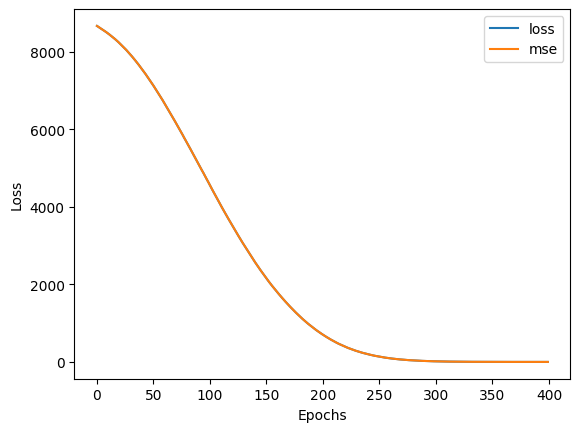

In [36]:
pd.DataFrame(history3.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


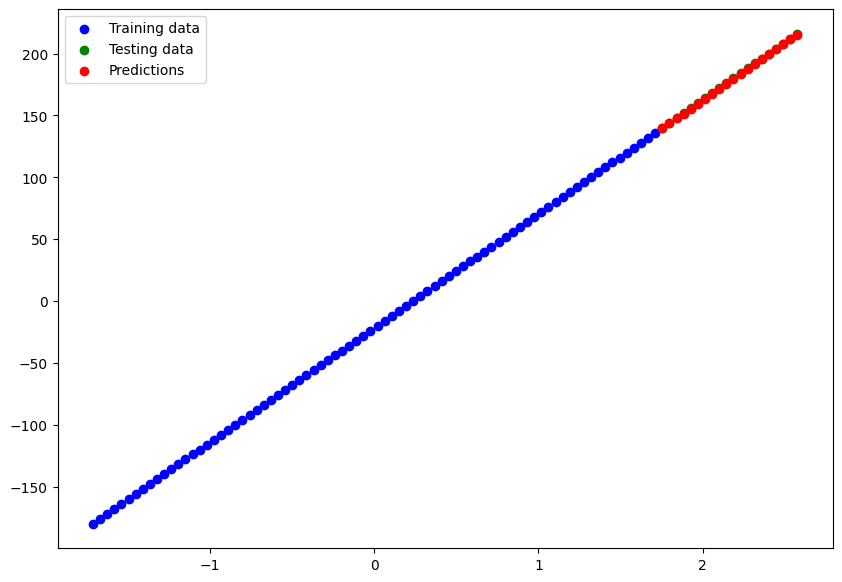

In [37]:
pred3 = model3.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred3
        )

#### **Model 4 - Overkill Approach**

A model with three hidden layers containing 16, 32, 64 neurons respectively with normalized features.  

##### Create and compile model

In [55]:
model4 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(64),
  tf.keras.layers.Dense(32),
  tf.keras.layers.Dense(16),
  tf.keras.layers.Dense(1)
])

model4.compile(loss='mse',
              optimizer='adam',
              metrics=["mse"]
              )

##### Show model summary

In [56]:
model4.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [57]:
history4 = model4.fit(x_train_scaled, y_train, 
                      epochs=50)

Epoch 1/50


I0000 00:00:1778753890.505914    4514 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33724__.10


1/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 9077.8809 - mse: 9077.8809

I0000 00:00:1778753891.411040    4514 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_33724__.10


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 408ms/step - loss: 9051.2920 - mse: 9051.2920
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9005.2051 - mse: 9005.2051  
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8958.2910 - mse: 8958.2910
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8911.9912 - mse: 8911.9912
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8866.4844 - mse: 8866.4844
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8815.5352 - mse: 8815.5352
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8759.4893 - mse: 8759.4893
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8696.9209 - mse: 8696.9209
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8627.0342 - mse: 8627.0342
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8545.7178 - mse: 8545.7178
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8452.1748 - mse: 8452.1748
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8350.3496 - mse: 8350.34

Evaluate the model.

In [58]:
model4.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - loss: 6.3550 - mse: 6.3550


[6.354987144470215, 6.354987144470215]

##### Showcase results

In [59]:
model4.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,261 (32.27 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,508 (21.52 KB)

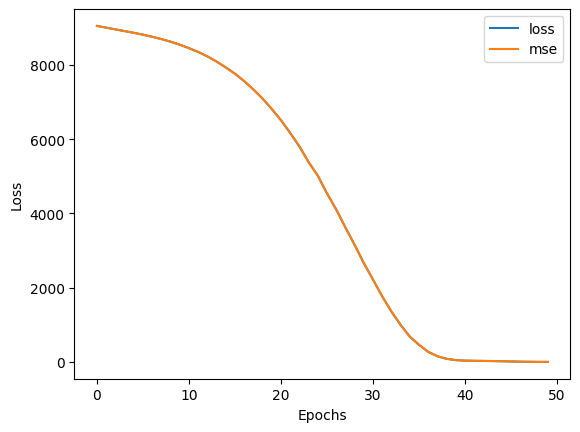

In [60]:
pd.DataFrame(history4.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


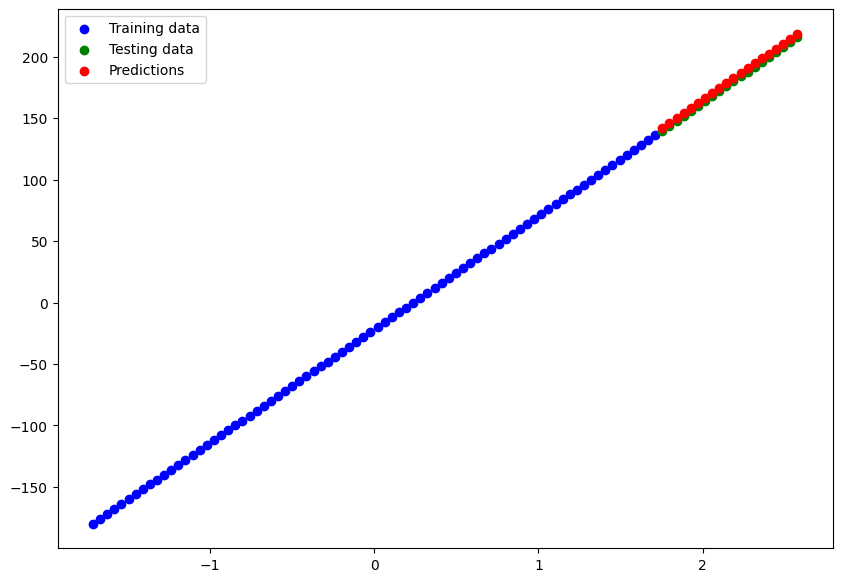

In [61]:
pred4 = model4.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred4
        )

#### **Model 5 - Overkill Approach w/o Normalization**

Same concept as Model 4 but instead, uses non-normalized or raw data for training and testing.

##### Create and compile model

In [47]:
model5 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(64),
  tf.keras.layers.Dense(32),
  tf.keras.layers.Dense(16),
  tf.keras.layers.Dense(1)
])

model5.compile(loss='mse',
              optimizer='adam',
              metrics=["mse"]
              )

##### Show model summary

In [48]:
model5.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [49]:
history5 = model5.fit(x_train, y_train, 
                      epochs=200)

Epoch 1/200


I0000 00:00:1778753824.055167    4516 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26953__.10


1/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 14647.9365 - mse: 14647.9365

I0000 00:00:1778753824.981343    4514 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26953__.10


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 420ms/step - loss: 11513.9531 - mse: 11513.9531
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6218.1201 - mse: 6218.1201
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2734.8901 - mse: 2734.8901
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 846.8970 - mse: 846.8970
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 330.4911 - mse: 330.4911
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 719.5391 - mse: 719.5391
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1036.9464 - mse: 1036.9464
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1025.1609 - mse: 1025.1609
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 763.8026 - mse: 763.8026
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 490.7098 - mse: 490.7098
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 340.7004 - mse: 340.7004
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 339.4269 - mse: 339.4269


Evaluate the model.

In [50]:
model5.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - loss: 10.8062 - mse: 10.8062


[10.806194305419922, 10.806194305419922]

##### Showcase results

In [51]:
model5.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,261 (32.27 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,508 (21.52 KB)

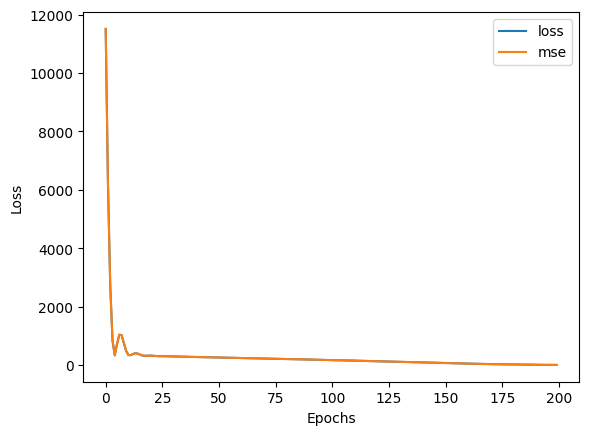

In [52]:
pd.DataFrame(history5.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


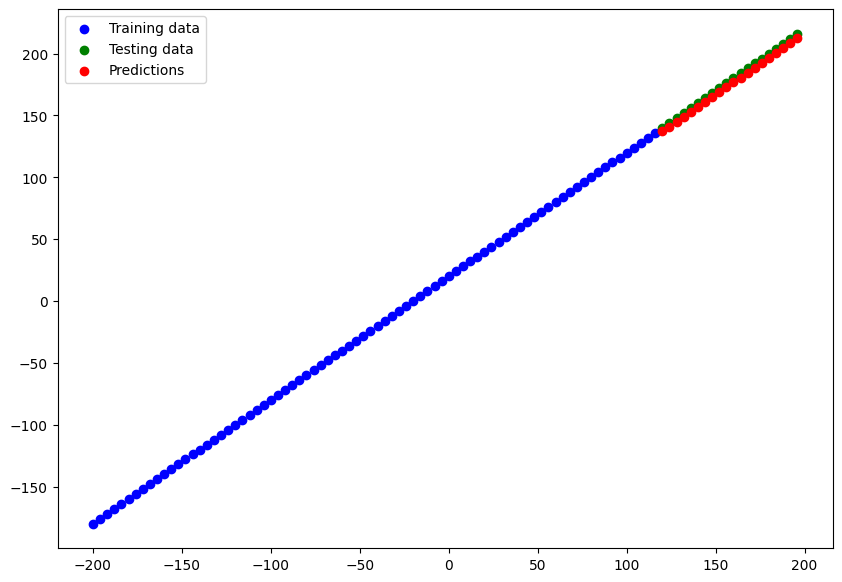

In [53]:
pred5 = model5.predict(x_test)

pltpred(x_train, y_train,
        x_test, y_test,
        pred5
        )

#### **Model 6 - Alternative Two Layer Approach**

Similar setup with Model 3 with a few modifications to layer parameter and learning rate, loss and optimizer functions.  

##### Create and compile model

In [169]:
model6 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1, activation='relu'),
  tf.keras.layers.Dense(1)
])

model6.compile(loss='mae',
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              metrics=["mae"]
              )

##### Show model summary

In [170]:
model6.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [171]:
history6 = model6.fit(x_train_scaled, y_train, 
                      epochs=100)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 80.7767 - mae: 80.7767
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 80.5070 - mae: 80.5070
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 80.1451 - mae: 80.1451
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 79.6450 - mae: 79.6450
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 79.0333 - mae: 79.0333
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 78.2190 - mae: 78.2190
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 77.0680 - mae: 77.0680
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 75.5913 - mae: 75.5913
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 73.9658 - mae: 73.9658
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 71.9282 - mae: 71.9282
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 69.4993 - mae: 69.4993
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 66.9576 - mae: 66.9576
Epoch 13/100
3/3 ━━━━━━━

Evaluate the model.

In [172]:
model6.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 22.1205 - mae: 22.1205


[22.120506286621094, 22.120506286621094]

##### Showcase results

In [173]:
model6.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

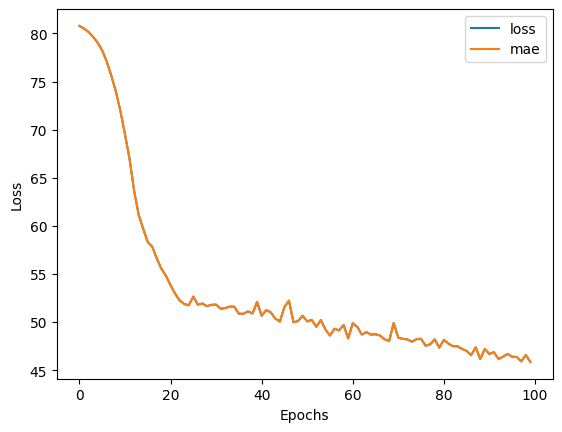

In [174]:
pd.DataFrame(history6.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


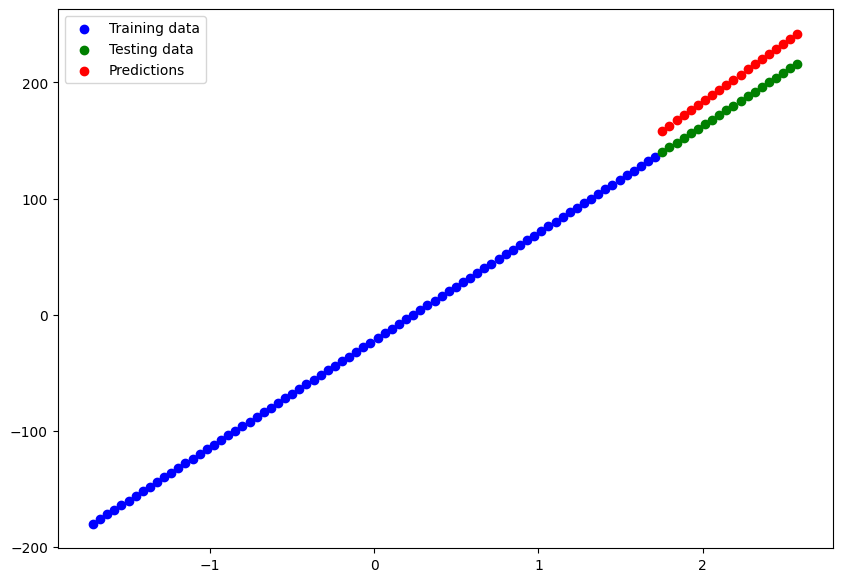

In [175]:
pred6 = model6.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred6
        )

#### **Model 7 - Aggressive Single Neuron Approach**

Similar setup with Model 1 but with increased learning rate and epoch count.  

##### Create and compile model

In [192]:
model7 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1)
])

model7.compile(loss='mse',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1.0),
              metrics=["mse"]
              )

##### Show model summary

In [193]:
model7.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [194]:
history7 = model7.fit(x_train_scaled, y_train, 
                      epochs=100)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 8700.0303 - mse: 8700.0303
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8094.6689 - mse: 8094.6689
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7458.8813 - mse: 7458.8813
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6917.6846 - mse: 6917.6846
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 6414.0811 - mse: 6414.0811
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5898.9438 - mse: 5898.9438
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5427.4360 - mse: 5427.4360
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5018.9990 - mse: 5018.9990
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4591.7148 - mse: 4591.7148
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4221.3413 - mse: 4221.3413
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3902.4739 - mse: 3902.4739
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 354

Evaluate the model.

In [195]:
model7.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - loss: 7.8138e-08 - mse: 7.8138e-08


[7.813796543132412e-08, 7.813796543132412e-08]

##### Showcase results

In [196]:
model7.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

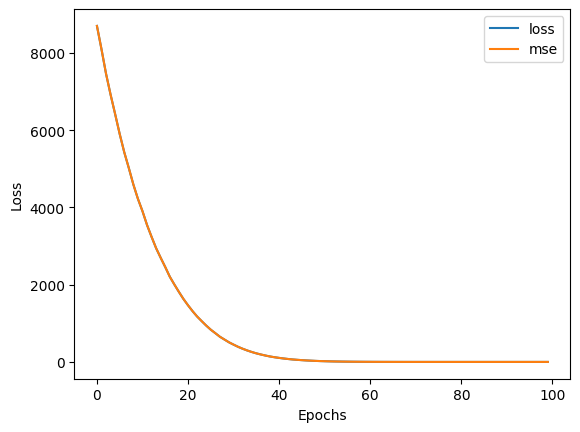

In [197]:
pd.DataFrame(history7.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


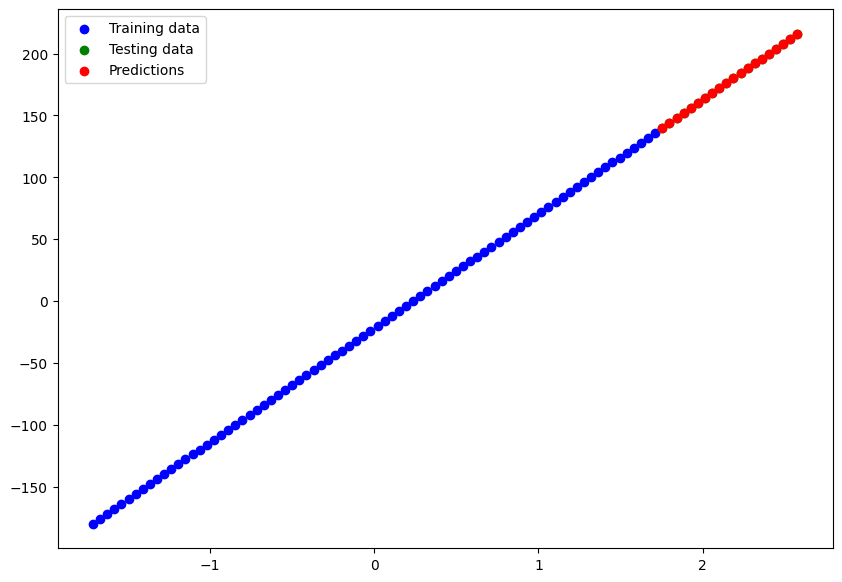

In [198]:
pred7 = model7.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred7
        )

#### **Model 8 - Two Layer Approach w/ low learning rate**

Same setup as Model 3 but with a rather low learning rate.  

##### Create and compile model

In [213]:
model8 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

model8.compile(loss='mse',
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.00001),
              metrics=["mse"]
              )

##### Show model summary

In [214]:
model8.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_73 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [215]:
history8 = model8.fit(x_train_scaled, y_train, 
                      epochs=800)

Epoch 1/800


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 9031.7207 - mse: 9031.7207
Epoch 2/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9031.1143 - mse: 9031.1143
Epoch 3/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9030.5039 - mse: 9030.5039
Epoch 4/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9029.9082 - mse: 9029.9082
Epoch 5/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9029.3125 - mse: 9029.3125
Epoch 6/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9028.7266 - mse: 9028.7266
Epoch 7/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9028.1064 - mse: 9028.1064  
Epoch 8/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9027.5439 - mse: 9027.5439
Epoch 9/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9026.9268 - mse: 9026.9268
Epoch 10/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9026.3223 - mse: 9026.3223
Epoch 11/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9025.7246 - mse: 9025.7246
Epoch 12/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9025.1514 - m

Evaluate the model.

In [216]:
model8.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - loss: 381.0432 - mse: 381.0432


[381.0432434082031, 381.0432434082031]

##### Showcase results

In [217]:
model8.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_73 (Dense)                │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

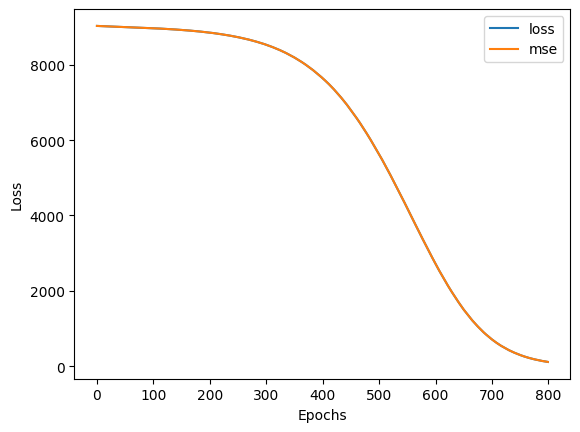

In [218]:
pd.DataFrame(history8.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


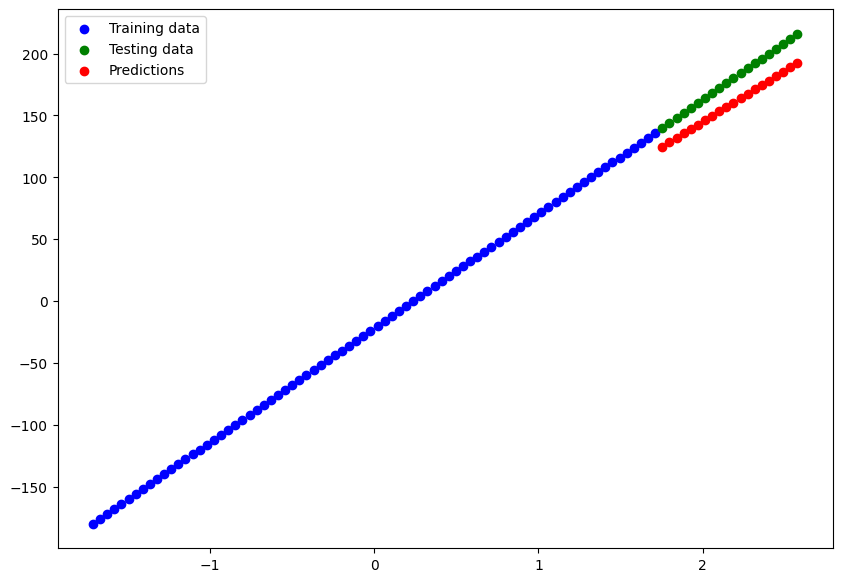

In [219]:
pred8 = model8.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred8
        )

#### **Model 9 - Yet Another Two Layer Approach**

Same setup as Model 3 but increased neuron count to a big amount for hidden layer and increased learning rate for optimizer.  

##### Create and compile model

In [254]:
model9 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(128),
  tf.keras.layers.Dense(1) 
])

model9.compile(loss='mse',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              metrics=["mse"]
              )

##### Show model summary

In [255]:
model9.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_85 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [256]:
history9 = model9.fit(x_train_scaled, y_train, 
                      epochs=50)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step - loss: 8602.4590 - mse: 8602.4590
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 5866.3140 - mse: 5866.3140
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2116.0159 - mse: 2116.0159
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 332.0523 - mse: 332.0523
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1250.7776 - mse: 1250.7776
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 717.9961 - mse: 717.9961
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 61.3171 - mse: 61.3171
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 271.5201 - mse: 271.5201
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 352.4856 - mse: 352.4856
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 112.0719 - mse: 112.0719
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 19.3232 - mse: 19.3232
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 110.1190 - mse: 110.1190
Epoch 13

Evaluate the model.

In [257]:
model9.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - loss: 0.0080 - mse: 0.0080


[0.008048554882407188, 0.008048554882407188]

##### Showcase results

In [258]:
model9.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_85 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,157 (4.52 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 772 (3.02 KB)

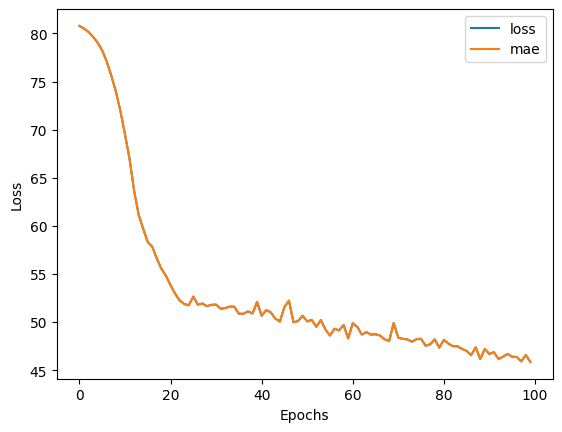

In [259]:
pd.DataFrame(history6.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


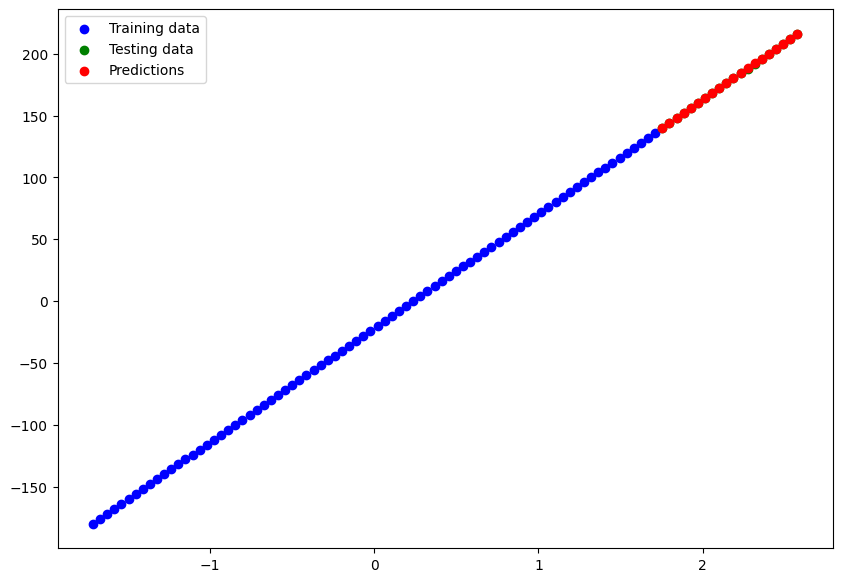

In [260]:
pred9 = model9.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred9
        )

#### **Model 10 - Redundant Multi-Layer Approach**

A model with multiple redundant layers containing the same neuron count.  

##### Create and compile model

In [261]:
model10 = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(1)
])

model10.compile(loss='mse',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mse"]
              )

##### Show model summary

In [262]:
model10.summary()

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_87 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

Fit the model and store its history

In [263]:
history10 = model10.fit(x_train_scaled, y_train, 
                      epochs=50)

Epoch 1/50


I0000 00:00:1778765066.190275    4514 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_167573__.11
I0000 00:00:1778765066.803203    4514 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778765067.702928   14232 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 164 bytes spill stores, 164 bytes spill loads

I0000 00:00:1778765067.751176    4514 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778765068.378919   14245 subprocess_compilation.cc:348] ptxas warning : Registers are spi

1/3 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step - loss: 8313.4082 - mse: 8313.4082

I0000 00:00:1778765069.960650    4513 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_167573__.11


3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 8976.8613 - mse: 8976.8613
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8692.6309 - mse: 8692.6309
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 7687.9541 - mse: 7687.9541
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 5367.0117 - mse: 5367.0117
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1720.2141 - mse: 1720.2141
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 842.1754 - mse: 842.1754
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1017.9672 - mse: 1017.9672
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 228.9334 - mse: 228.9334
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 750.2051 - mse: 750.2051
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 549.6730 - mse: 549.6730
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 175.4552 - mse: 175.4552
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 181.7795 - mse: 181.7795
Epoch 13/50
3/

Evaluate the model.

In [264]:
model10.evaluate(x_test_scaled, y_test)

I0000 00:00:1778765075.644294    4513 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778765076.689746   16215 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 164 bytes spill stores, 164 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 7.6142 - mse: 7.6142


[7.614233493804932, 7.614233493804932]

##### Showcase results

In [265]:
model10.summary()

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_87 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,021 (148.52 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,348 (99.02 KB)

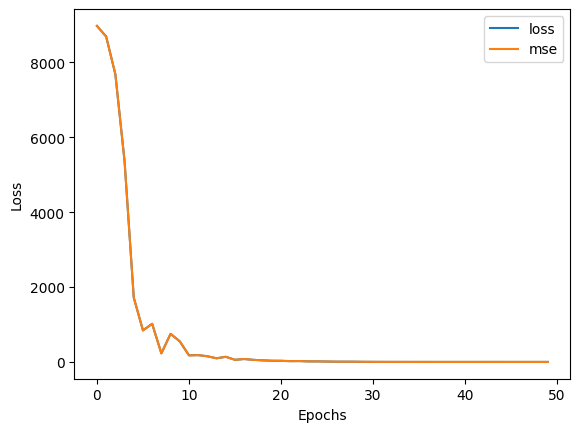

In [266]:
pd.DataFrame(history10.history).plot()
mpl.pyplot.xlabel("Epochs")
mpl.pyplot.ylabel("Loss");

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step


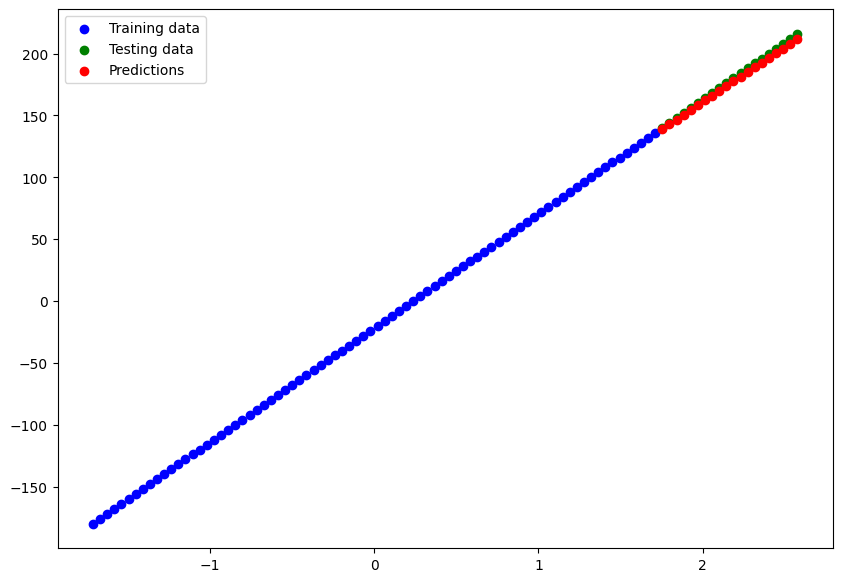

In [267]:
pred10 = model10.predict(x_test_scaled)

pltpred(x_train_scaled, y_train,
        x_test_scaled, y_test,
        pred10
        )